# Session 5 Peaks

In [1]:
import jupytext

In [ ]:
# Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [ ]:
# Load data

In [3]:
# Load pulse data
data = pd.read_csv("data/pulse_data.csv")

# Preview data
data.head()

,time,absorption
0,25.342069,1388
1,25.344575,1388
2,25.347080,1385
3,25.349586,1383
4,25.352091,1383


In [ ]:
# Plot Signal

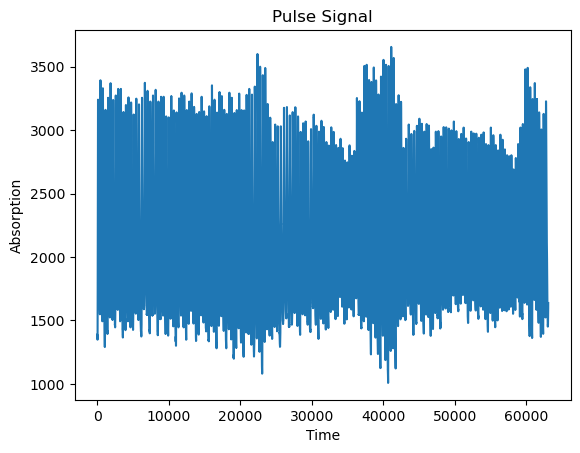

In [4]:
# Plot absorption signal
plt.plot(data.absorption)
plt.title("Pulse Signal")
plt.xlabel("Time")
plt.ylabel("Absorption")
plt.show()

In [ ]:
# Peak Detection

In [5]:
# Detect all peaks (includes noise)
peaks, properties = find_peaks(data.absorption)

len(peaks)

# Without constraints, find_peaks detects all local maxima,
# including noise and small fluctuations

637

In [ ]:
# Fix: Filter Peaks

In [12]:
# Detect meaningful peaks using filtering
peaks, properties = find_peaks(
    data.absorption,
    height=2800,
    distance=120
)

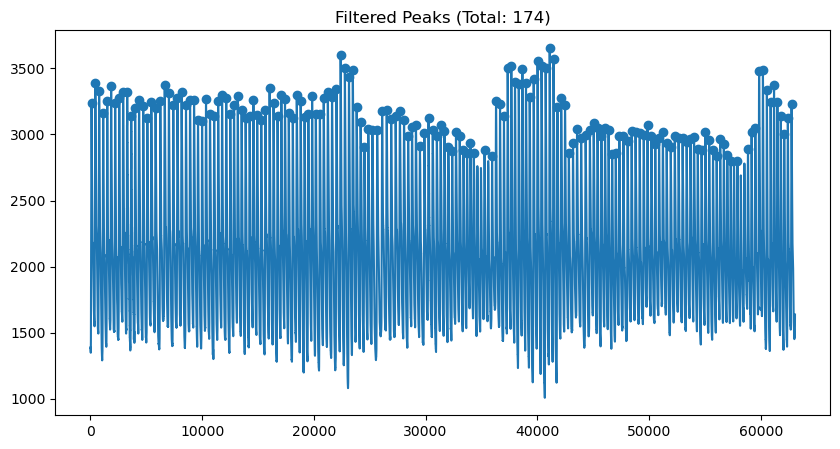

In [13]:
# Plot with peaks

plt.figure(figsize=(10,5))
plt.plot(data.absorption)
plt.scatter(peaks, data.absorption.iloc[peaks])
plt.title(f"Filtered Peaks (Total: {len(peaks)})")
plt.show()

In [14]:
data.absorption.describe()

count    63065.000000
mean      2119.898993
std        544.475394
min       1007.000000
25%       1645.000000
50%       2066.000000
75%       2498.000000
max       3656.000000
Name: absorption, dtype: float64

In [ ]:
# The absorption signal ranges from ~1000 to ~3600. 
# Initial peak detection resulted in 401 peaks due to the absence of filtering. 
# By setting a height threshold around 2500 and enforcing a minimum distance between peaks, 
# we successfully removed noise and retained physiologically meaningful peaks.